# Practice quiz: Multiclass Classification

## Question 1

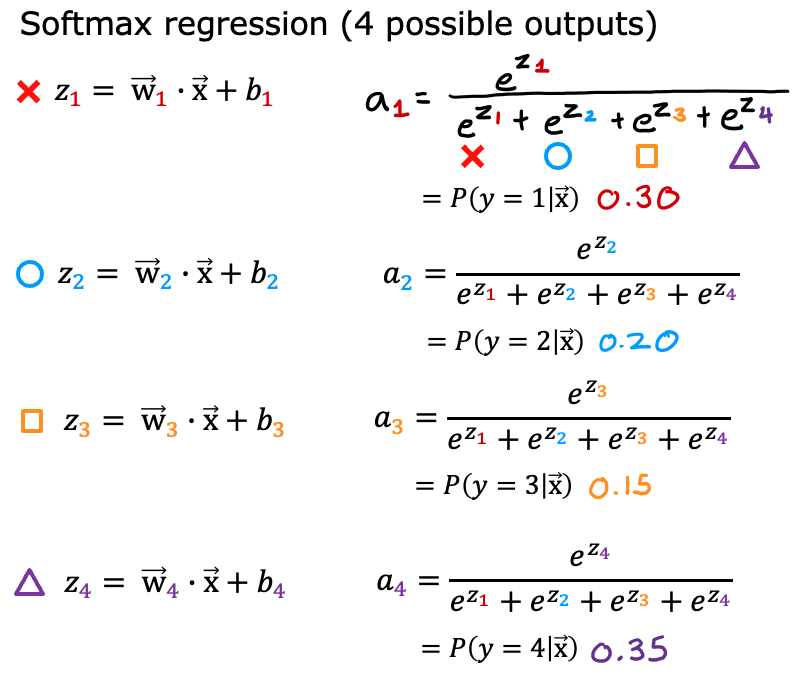

**For a multiclass classification task that has 4 possible outputs, the sum of all the activations adds up to 1. For a multiclass classification task that has 3 possible outputs, the sum of all the activations should add up to ....**

- [ ] 1
- [ ] More than 1
- [ ] Less than 1
- [ ] It will vary, depending on the input x

### Correct Answer Identification
- ✅ **1**

### Explanation of Correct Answer

The sum of all activations in **softmax regression** always equals **1**, regardless of the number of classes. This is a fundamental property of the softmax function, which is designed to produce a **probability distribution** over all possible classes.

For a problem with N classes, the softmax function is defined as:

$$a_j = \frac{e^{z_j}}{\sum_{k=1}^{N} e^{z_k}} = P(y = j|\vec{x})$$

The denominator ensures normalization:
$$\sum_{j=1}^{N} a_j = \sum_{j=1}^{N} \frac{e^{z_j}}{\sum_{k=1}^{N} e^{z_k}} = \frac{\sum_{j=1}^{N} e^{z_j}}{\sum_{k=1}^{N} e^{z_k}} = 1$$

### Why This Matters

This property makes softmax outputs interpretable as **probabilities**:
- Each activation $a_j$ represents the probability that the input belongs to class $j$
- The class with the highest probability is the model's prediction
- The sum of probabilities across all classes must be 1 (the input must belong to exactly one class)

### Explanation of Incorrect Options

#### ❌ More than 1
- This would violate probability axioms (probabilities cannot sum to more than 1)
- Would make outputs uninterpretable as probabilities

#### ❌ Less than 1
- Would mean the model isn't accounting for all possible classes
- The input must belong to one of the classes, so probabilities should sum to 1

#### ❌ It will vary, depending on the input x
- While individual $a_j$ values vary with input, their sum is **always** 1
- This is enforced by the softmax denominator

### Real-World Examples

**Multiclass Classification (N classes, sum of probabilities = 1):**
- **Handwritten digit recognition:** MNIST dataset has 10 classes (digits 0-9). For any image, the probabilities of it being each digit must sum to 1
- **Animal species classification:** Given a photo, the model outputs probabilities for "dog," "cat," "bird," etc., which must sum to 1
- **News article categorization:** Probabilities for "sports," "politics," "technology," "entertainment" sum to 1

---

## Question 2

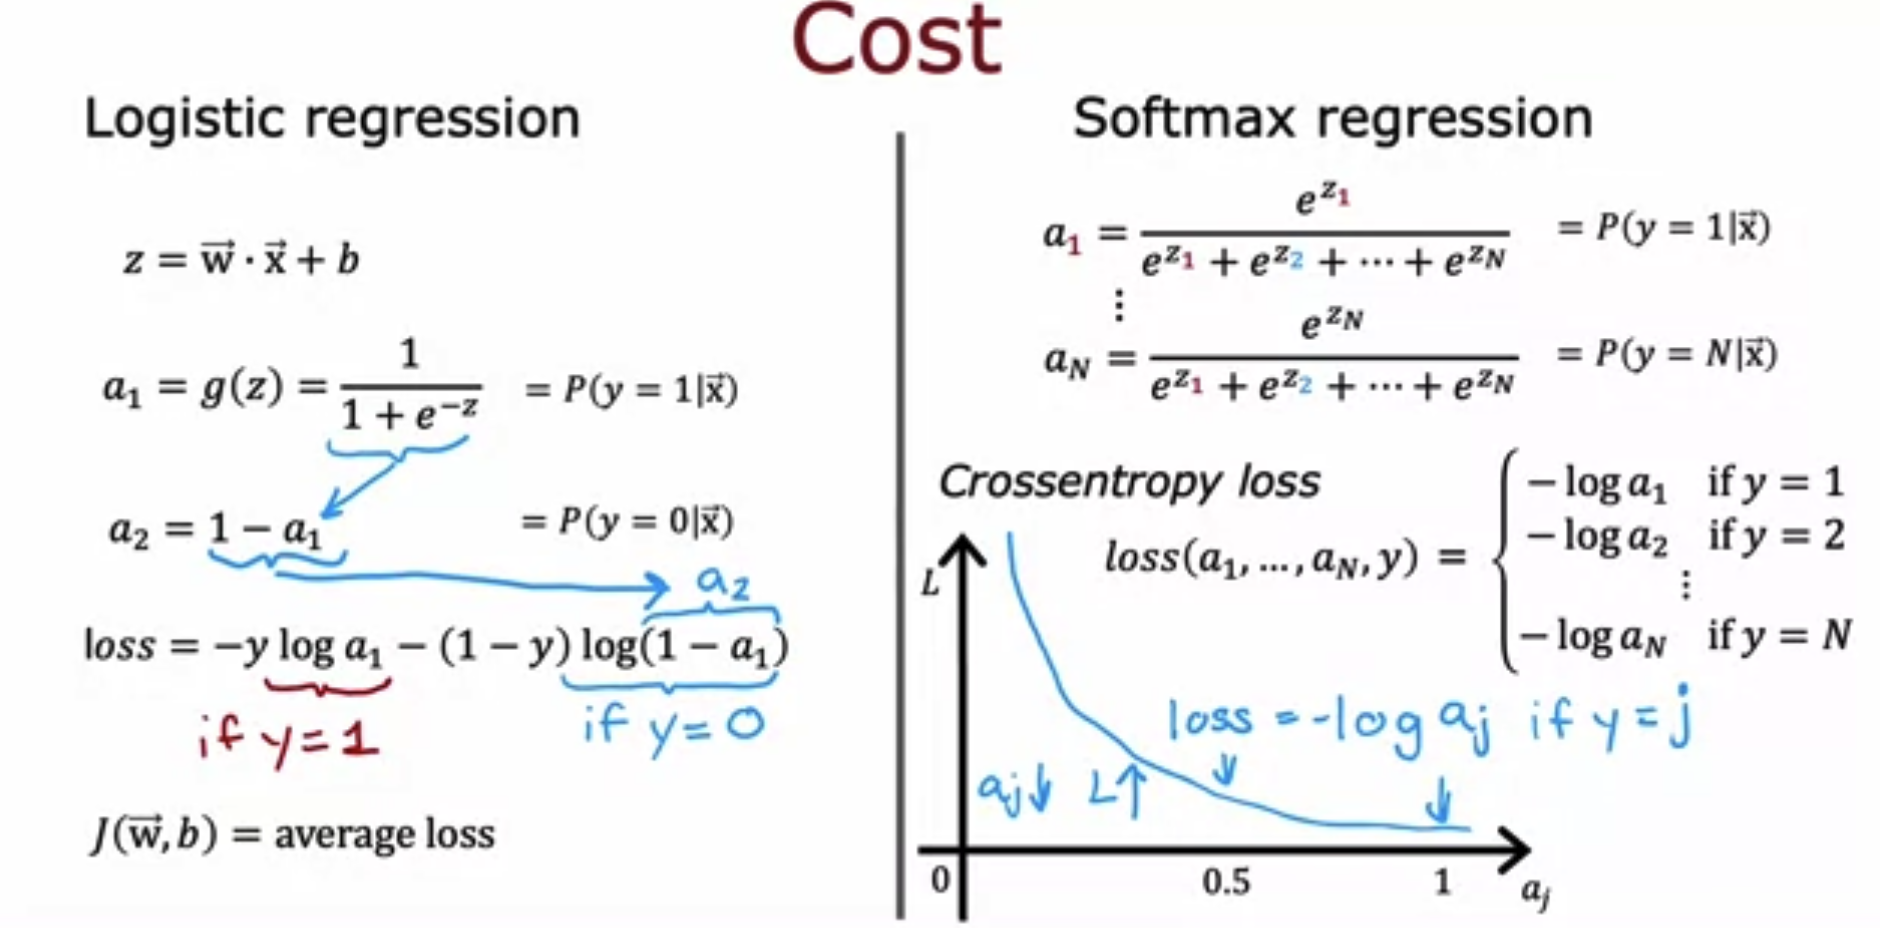

**For multiclass classification, the cross entropy loss is used for training the model. If there are 4 possible classes for the output, and for a particular training example, the true class of the example is class 3 (y=3), then what does the cross entropy loss simplify to? [Hint: This loss should get smaller when $a_3$ gets larger.]**

- [ ] $-\log(a_3)$
- [ ] $\frac{\log(a_1) + \log(a_2) + \log(a_3) + \log(a_4)}{4}$
- [ ] $z_3 / (z_1 + z_2 + z_3 + z_4)$
- [ ] $z_3$

### Correct Answer Identification
- ✅ **$-\log(a_3)$**

### Explanation of Correct Answer

The cross-entropy loss for a single training example in multiclass classification is:

$$\text{loss} = -\log(a_{\text{true class}})$$

Where $a_{\text{true class}}$ is the activation (probability) corresponding to the correct class.

For this specific case where $y = 3$:
$$\text{loss} = -\log(a_3)$$

### Why This Makes Sense

The hint tells us: *"This loss should get smaller when $a_3$ gets larger"*

Let's verify:
- When $a_3$ is close to 1 (model is very confident and correct), $-\log(1) = 0$ (minimum loss)
- When $a_3$ is close to 0 (model is very wrong), $-\log(0) \to \infty$ (maximum loss)
- This matches our intuition - we want to **minimize** loss when the model is correct and confident

### Mathematical Derivation

The general cross-entropy loss can be written as:
$$\text{loss} = -\sum_{j=1}^{N} y_j \log(a_j)$$

Where $y_j$ is 1 for the true class and 0 for all others (one-hot encoding). For $y=3$:
- $y_1 = 0$, $y_2 = 0$, $y_3 = 1$, $y_4 = 0$

Substituting:
$$\text{loss} = -(0 \cdot \log(a_1) + 0 \cdot \log(a_2) + 1 \cdot \log(a_3) + 0 \cdot \log(a_4)) = -\log(a_3)$$

### Explanation of Incorrect Options

#### ❌ $\frac{\log(a_1) + \log(a_2) + \log(a_3) + \log(a_4)}{4}$
- This averages the logs of all class probabilities
- Would penalize the model even when it assigns low probability to incorrect classes (which is actually good!)
- Doesn't match the one-hot encoding pattern

#### ❌ $z_3 / (z_1 + z_2 + z_3 + z_4)$
- This is actually the formula for $a_3$ (the probability), not the loss
- Loss should be **small** when probability is high; this expression would be **large** when probability is high

#### ❌ $z_3$
- This is just the raw logit (pre-activation) value
- Not normalized and doesn't have the logarithmic relationship needed for proper gradient behavior
- Can be any real number, not suitable as a loss function

### Real-World Example

**Medical Diagnosis:**
- Classes: 1 = "healthy", 2 = "flu", 3 = "COVID-19", 4 = "pneumonia"
- Patient actually has COVID-19 ($y=3$)
- Model predicts: $a_1=0.1$, $a_2=0.1$, $a_3=0.7$, $a_4=0.1$
- Loss = $-\log(0.7) \approx 0.36$ (low, good!)
- If model incorrectly predicted $a_3=0.2$: loss = $-\log(0.2) \approx 1.61$ (higher, worse)

---

## Question 3

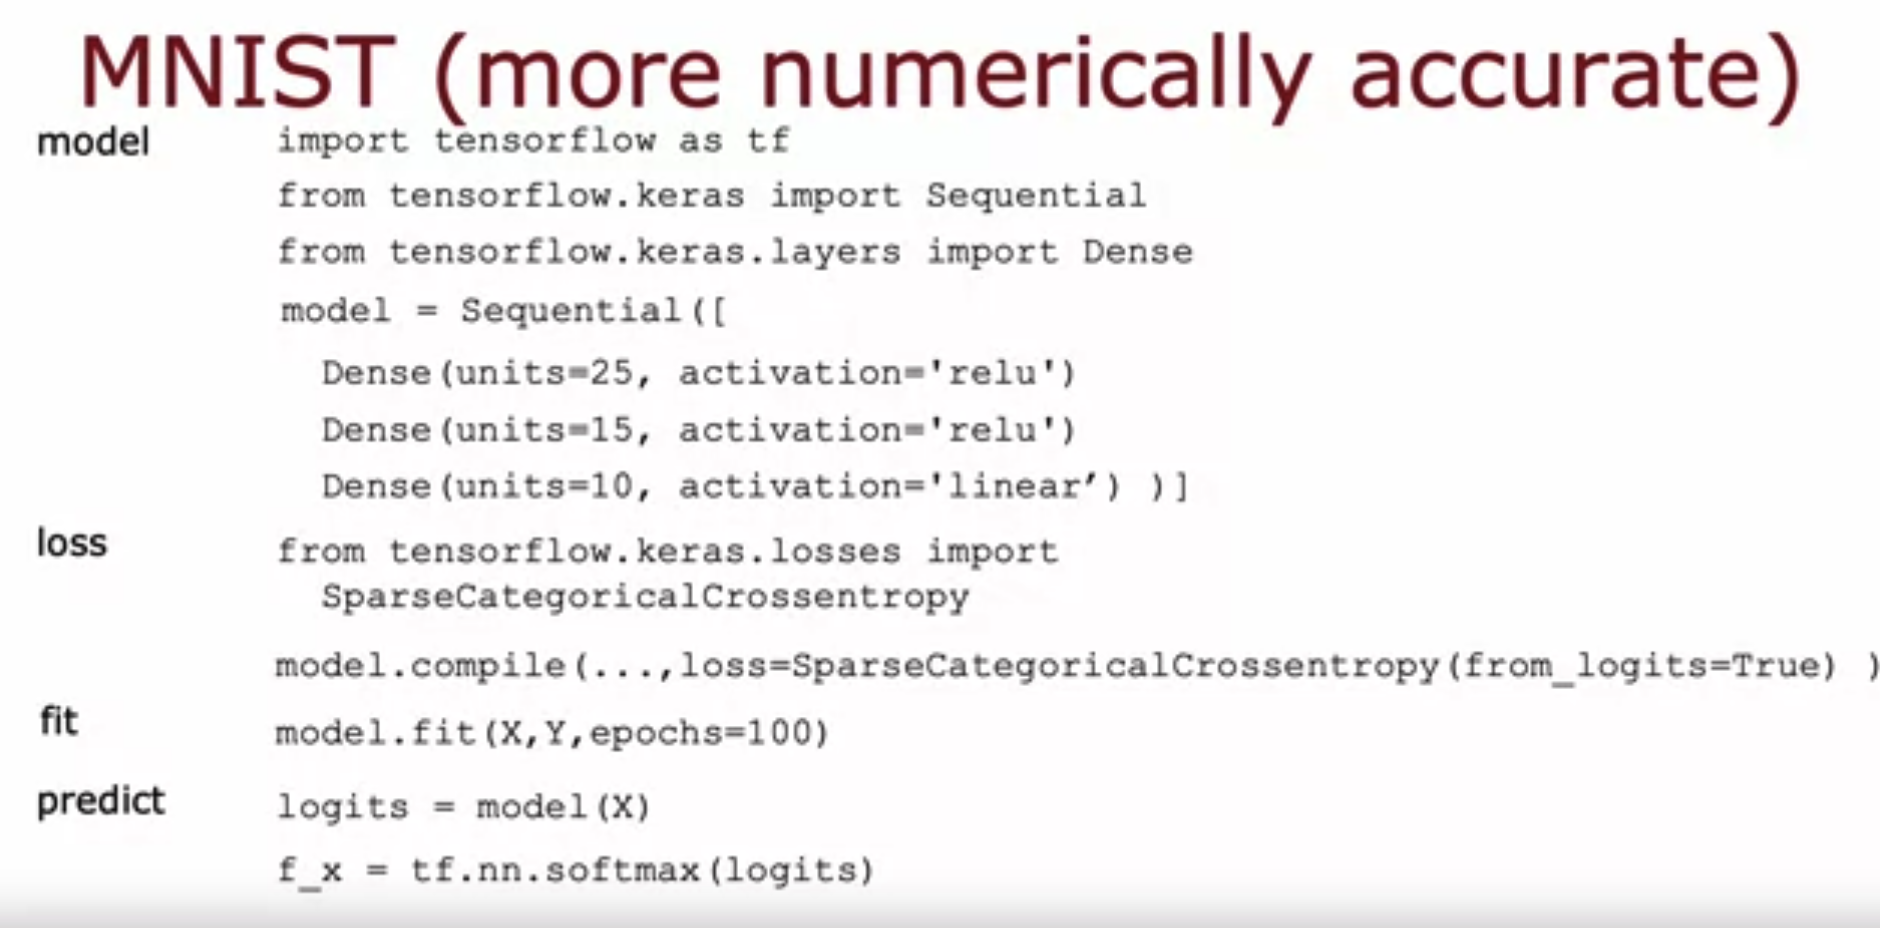

**For multiclass classification, the recommended way to implement softmax regression is to set from_logits=True in the loss function, and also to define the model's output layer with...**

- [ ] a 'linear' activation
- [ ] a 'softmax' activation

### Correct Answer Identification
- ✅ **a 'linear' activation**

### Explanation of Correct Answer

When using `from_logits=True` in `SparseCategoricalCrossentropy`, the output layer should have **'linear' activation** (i.e., no activation function). This is the recommended practice for numerical stability.

```python
model = Sequential([
    Dense(units=25, activation='relu'),
    Dense(units=15, activation='relu'),
    Dense(units=10, activation='linear')  # Note: linear, not softmax
])

model.compile(
    loss=SparseCategoricalCrossentropy(from_logits=True)
)
```

### Why This is Recommended

#### Numerical Stability
The softmax function involves exponentials ($e^{z_j}$), which can cause:
- **Overflow:** Very large $z_j$ values lead to extremely large exponentials
- **Underflow:** Very negative $z_j$ values lead to extremely small exponentials

By combining softmax with the loss calculation internally, TensorFlow can use **mathematical equivalences** to compute the loss more stably:

$$\text{loss} = -\log\left(\frac{e^{z_{\text{true}}}}{\sum_j e^{z_j}}\right) = -z_{\text{true}} + \log\left(\sum_j e^{z_j}\right)$$

This **LogSumExp trick** avoids computing large exponentials directly.

### Comparison of Approaches

| Approach | Output Layer | Loss Function | When to Use |
|----------|-------------|---------------|-------------|
| **Recommended** | `activation='linear'` | `from_logits=True` | Most cases (more stable) |
| Alternative | `activation='softmax'` | `from_logits=False` | When you need probabilities directly from model |

### Explanation of Incorrect Option

#### ❌ a 'softmax' activation
If you use `activation='softmax'` in the output layer:
- The model outputs probabilities directly ($a_j$ values)
- Using `from_logits=True` would be incorrect because the model is already applying softmax
- This can lead to **double softmax** (applying softmax twice), which distorts probabilities
- Less numerically stable for very confident predictions

### Complete Implementation Example

```python
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Define model with linear output layer
model = Sequential([
    Dense(units=25, activation='relu'),
    Dense(units=15, activation='relu'),
    Dense(units=10, activation='linear')  # 10 classes (e.g., digits 0-9)
])

# Compile with from_logits=True
model.compile(
    loss=SparseCategoricalCrossentropy(from_logits=True)
)

# Training
model.fit(X, Y, epochs=100)

# For predictions, apply softmax to get probabilities
logits = model(X)  # Raw outputs (logits)
probabilities = tf.nn.softmax(logits)  # Convert to probabilities
predictions = tf.argmax(probabilities, axis=1)  # Get predicted class
```

### Real-World Application

**MNIST Digit Recognition:**
- **Input:** 28×28 pixel images of handwritten digits
- **Output:** 10 classes (digits 0-9)
- Using `linear` output with `from_logits=True` ensures stable training even when the model becomes very confident about certain digits
- During prediction, we apply softmax to get interpretable probabilities (e.g., "90% confident this is a 7")

---

## Summary Table: Softmax Regression Best Practices

| Aspect | Recommendation | Reason |
|--------|---------------|--------|
| **Output Layer Activation** | `'linear'` | Enables numerically stable loss computation |
| **Loss Function** | `SparseCategoricalCrossentropy(from_logits=True)` | Uses LogSumExp trick internally |
| **Prediction** | Apply `tf.nn.softmax()` to logits | Convert to interpretable probabilities |
| **Number of Output Units** | Equal to number of classes | One unit per possible class |
| **Sum of Activations** | Always equals 1 | Softmax produces probability distribution |

**Key Takeaway:** Always use the `from_logits=True` approach with linear output layer for multiclass classification - it's more numerically stable and is the standard practice in modern deep learning frameworks.